<a href="https://colab.research.google.com/github/levisadoh/Bitcoin-Historical-Data-Analysis-2014-2026-/blob/main/MyBitcoinproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Setup & Data Cleaning of my dataset


In [1]:
import numpy as np
import pandas as pd

In [2]:
bitcoin= pd.read_csv('bitcoin_dataset.csv')
bitcoin.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [3]:
bitcoin['year'] = pd.to_datetime(bitcoin['Date']).dt.year
bitcoin['month'] = pd.to_datetime(bitcoin['Date']).dt.month
bitcoin['day'] = pd.to_datetime(bitcoin['Date']).dt.day
bitcoin.head()


,Date,Open,High,Low,Close,Adj Close,Volume,year,month,day
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800,2014,9,17
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200,2014,9,18
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700,2014,9,19
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600,2014,9,20
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100,2014,9,21


In [4]:
bitcoin.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
4275,False
4276,False
4277,False
4278,False


In [5]:
bitcoin.index = pd.to_datetime(bitcoin['Date'])
bitcoin.head()

,Date,Open,High,Low,Close,Adj Close,Volume,year,month,day
Date,,,,,,,,,,
2014-09-17,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800,2014,9,17
2014-09-18,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200,2014,9,18
2014-09-19,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700,2014,9,19
2014-09-20,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600,2014,9,20
2014-09-21,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100,2014,9,21


In [6]:
bitcoin.Date.duplicated()

,Date
Date,
2014-09-17,False
2014-09-18,False
2014-09-19,False
2014-09-20,False
2014-09-21,False
...,...
2026-06-01,False
2026-06-02,False
2026-06-03,False


In [7]:
bitcoin_drop= bitcoin.drop(['Adj Close','Date'], axis=1)

bitcoin_drop.head()

,Open,High,Low,Close,Volume,year,month,day
Date,,,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,21056800,2014,9,17
2014-09-18,456.859985,456.859985,413.104004,424.440002,34483200,2014,9,18
2014-09-19,424.102997,427.834991,384.532013,394.795990,37919700,2014,9,19
2014-09-20,394.673004,423.295990,389.882996,408.903992,36863600,2014,9,20
2014-09-21,408.084991,412.425995,393.181000,398.821014,26580100,2014,9,21


In [8]:
bitcoin_drop.describe()

,Open,High,Low,Close,Volume,year,month,day
count,4280.000000,4280.000000,4280.000000,4280.000000,4.280000e+03,4280.000000,4280.000000,4280.000000
mean,28623.330630,29188.324150,28019.749124,28636.451670,2.230348e+10,2020.070093,6.502570,15.739486
std,32442.204251,32986.012544,31852.792883,32442.454923,2.294359e+10,3.404387,3.484281,8.806514
min,176.897003,211.731003,171.509995,178.102997,5.914570e+06,2014.000000,1.000000,1.000000
25%,3452.187439,3504.092224,3391.943420,3458.813721,1.676575e+09,2017.000000,3.000000,8.000000
50%,11536.727539,11850.328613,11288.414062,11564.331543,1.802679e+10,2020.000000,6.000000,16.000000
75%,46401.472656,47432.591797,45184.174805,46446.924805,3.446429e+10,2023.000000,10.000000,23.000000
max,124752.140625,126198.070312,123196.046875,124752.531250,3.509679e+11,2026.000000,12.000000,31.000000


Ploting the closing price over time — this is the headline chart and tells the full Bitcoin story at a glance

In [9]:
import numpy as np
import matplotlib.pyplot as plt

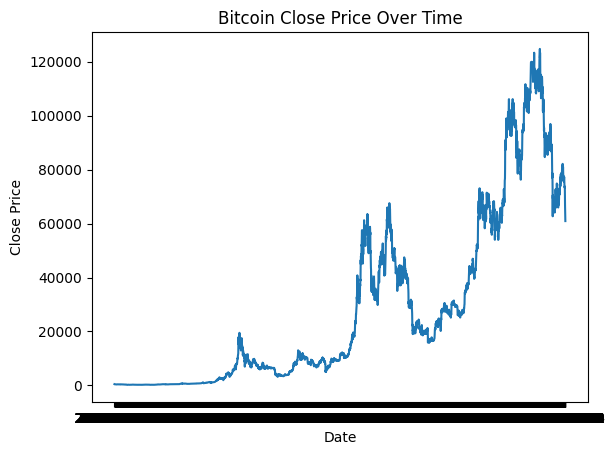

In [10]:
X = bitcoin['Close']
Y = bitcoin['Date']

fig, ax = plt.subplots()
ax.plot(Y, X)
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Bitcoin Close Price Over Time')
plt.show()

Ploting trading volume over time — spikes in volume often coincide with big price moves

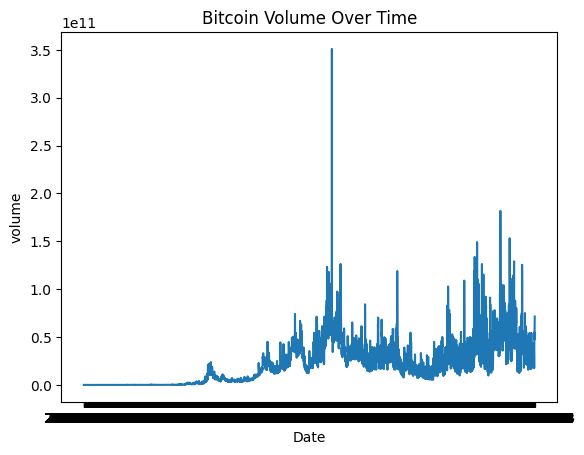

In [11]:
X = bitcoin['Volume']
Y = bitcoin['Date']

fig,ax=plt.subplots()
ax.plot(Y,X)
plt.xlabel('Date')
plt.ylabel('volume')
plt.title('Bitcoin Volume Over Time')
plt.show()

how much % Bitcoin moved each day

In [12]:
bitcoin_drop['daily return'] = (bitcoin_drop['Close'] - bitcoin_drop['Open'])/(bitcoin_drop['Open']*100)
bitcoin_drop.head()


,Open,High,Low,Close,Volume,year,month,day,daily return
Date,,,,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,21056800,2014,9,17,-0.000183
2014-09-18,456.859985,456.859985,413.104004,424.440002,34483200,2014,9,18,-0.000710
2014-09-19,424.102997,427.834991,384.532013,394.795990,37919700,2014,9,19,-0.000691
2014-09-20,394.673004,423.295990,389.882996,408.903992,36863600,2014,9,20,0.000361
2014-09-21,408.084991,412.425995,393.181000,398.821014,26580100,2014,9,21,-0.000227


how volatile each day was

In [13]:
bitcoin_drop['Daily Range'] = (bitcoin_drop['High']- bitcoin_drop['Low'])
bitcoin_drop.head()

,Open,High,Low,Close,Volume,year,month,day,daily return,Daily Range
Date,,,,,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,21056800,2014,9,17,-0.000183,15.752014
2014-09-18,456.859985,456.859985,413.104004,424.440002,34483200,2014,9,18,-0.000710,43.755981
2014-09-19,424.102997,427.834991,384.532013,394.795990,37919700,2014,9,19,-0.000691,43.302979
2014-09-20,394.673004,423.295990,389.882996,408.903992,36863600,2014,9,20,0.000361,33.412994
2014-09-21,408.084991,412.425995,393.181000,398.821014,26580100,2014,9,21,-0.000227,19.244995


standard in finance for compounding analysis

In [14]:
bitcoin_drop['Log Return']=np.log(bitcoin_drop['Close'] / bitcoin_drop['Close'].shift(1))
bitcoin_drop.head()

,Open,High,Low,Close,Volume,year,month,day,daily return,Daily Range,Log Return
Date,,,,,,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,21056800,2014,9,17,-0.000183,15.752014,NaN
2014-09-18,456.859985,456.859985,413.104004,424.440002,34483200,2014,9,18,-0.000710,43.755981,-0.074643
2014-09-19,424.102997,427.834991,384.532013,394.795990,37919700,2014,9,19,-0.000691,43.302979,-0.072402
2014-09-20,394.673004,423.295990,389.882996,408.903992,36863600,2014,9,20,0.000361,33.412994,0.035111
2014-09-21,408.084991,412.425995,393.181000,398.821014,26580100,2014,9,21,-0.000227,19.244995,-0.024968


Bitcoin's growth per year

In [15]:
bitcoin_drop.groupby('year').sum()

,Open,High,Low,Close,Volume,month,day,daily return,Daily Range,Log Return
year,,,,,,,,,,
2014,3.869617e+04,3.956613e+04,3.772579e+04,3.855147e+04,2526711120,1138,1786,-0.003129,1.840337e+03,-0.356490
2015,9.933439e+04,1.015255e+05,9.738488e+04,9.944548e+04,12375531708,2382,5738,0.005187,4.140592e+03,0.296179
2016,2.075738e+05,2.101946e+05,2.051259e+05,2.080682e+05,31448370984,2384,5767,0.008505,5.068697e+03,0.805722
2017,1.449285e+06,1.512811e+06,1.391273e+06,1.462202e+06,869746420804,2382,5738,0.030737,1.215376e+05,2.687097
2018,2.774372e+06,2.842612e+06,2.683023e+06,2.763889e+06,2213196541089,2382,5738,-0.010208,1.595893e+05,-1.330359
2019,2.695605e+06,2.755716e+06,2.636250e+06,2.699265e+06,6106628278860,2382,5738,0.009112,1.194662e+05,0.653384
2020,4.046784e+06,4.137395e+06,3.969122e+06,4.068594e+06,12086518388859,2384,5767,0.016672,1.682736e+05,1.394164
2021,1.730177e+07,1.779849e+07,1.673598e+07,1.731448e+07,17211845901724,2382,5738,0.007004,1.062513e+06,0.467926
2022,1.032172e+07,1.051850e+07,1.008024e+07,1.029218e+07,10954842244160,2382,5738,-0.008163,4.382574e+05,-1.029046


Bitcoin's growth per Month

In [16]:
bitcoin_drop.groupby('month').mean()

,Open,High,Low,Close,Volume,year,day,daily return,Daily Range,Log Return
month,,,,,,,,,,
1,29687.746617,30302.531856,28954.814032,29687.833212,2.410004e+10,2020.500000,16.000000,-0.000001,1347.717824,-0.001082
2,28973.387119,29635.266734,28224.999625,28992.714207,2.580339e+10,2020.495575,14.628319,0.000036,1410.267109,0.002949
3,30434.653560,31192.035499,29691.953500,30503.382405,2.414452e+10,2020.500000,16.000000,0.000004,1500.081999,-0.000363
4,31304.963980,31917.871662,30658.421597,31323.565866,2.261248e+10,2020.500000,15.500000,0.000031,1259.450065,0.002810
5,31707.807595,32305.447685,31026.770836,31679.476820,2.445714e+10,2020.500000,16.000000,0.000020,1278.676849,0.001397
6,26923.418474,27371.368322,26326.145074,26849.965048,1.950525e+10,2020.089552,15.313433,0.000001,1045.223248,-0.000512
7,26758.625535,27242.191296,26326.359454,26825.036264,1.919176e+10,2020.000000,16.000000,0.000031,915.831842,0.002622
8,27709.386108,28177.096888,27174.813324,27671.936334,2.017557e+10,2020.000000,16.000000,-0.000003,1002.283564,-0.000656
9,25953.739260,26348.544985,25531.516554,25967.578655,1.929519e+10,2019.755814,15.825581,-0.000007,817.028431,-0.001156


visual annotation on major crashes (2018, 2022) and peaks (2021, 2024) on the price chart

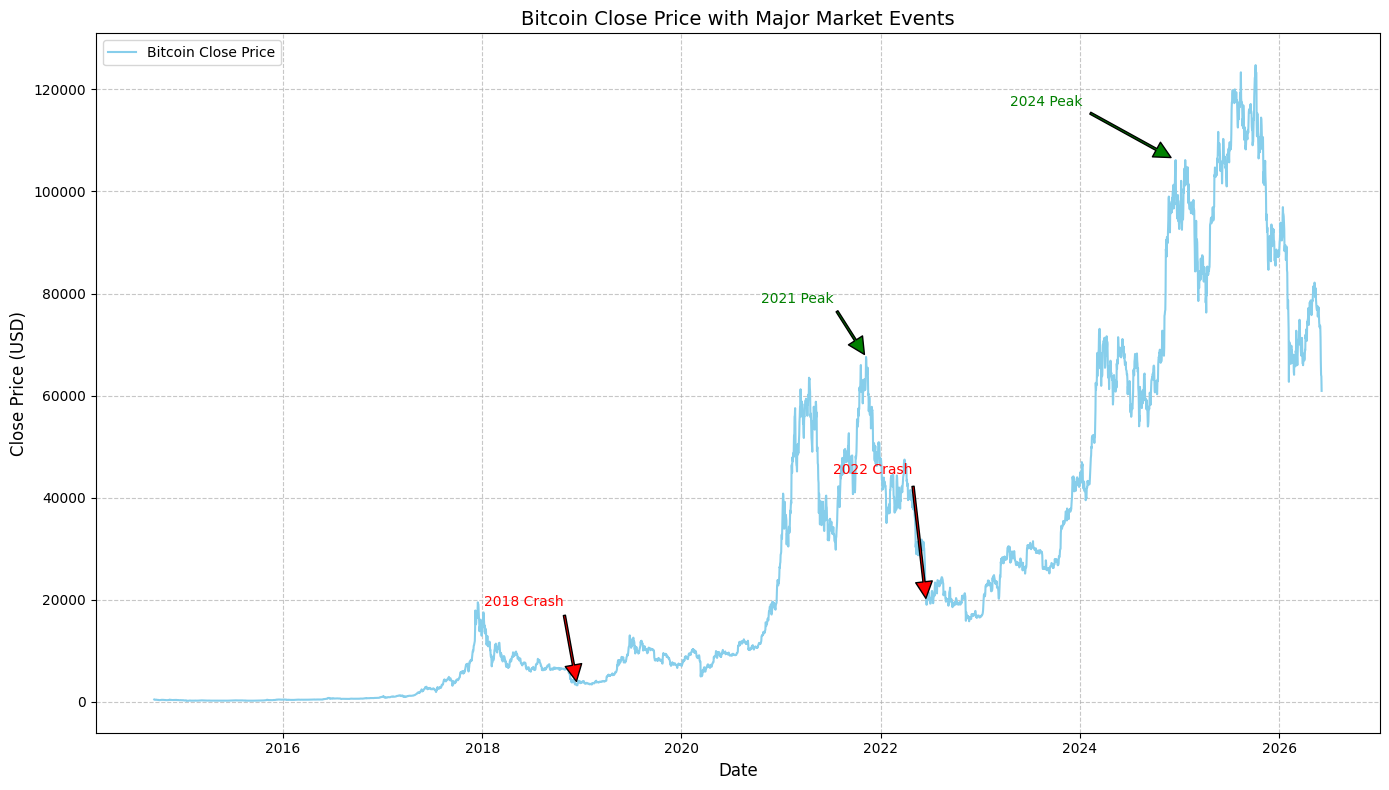

In [17]:
plt.figure(figsize=(14, 8))
plt.plot(bitcoin.index, bitcoin['Close'], label='Bitcoin Close Price', color='skyblue')

# Annotate Crashes

# 2018 Crash: Find the minimum close price between October 2018 and January 2019
crash_2018_date = bitcoin.loc['2018-10':'2019-01', 'Close'].idxmin()
crash_2018_price = bitcoin.loc[crash_2018_date, 'Close']
plt.annotate('2018 Crash', xy=(crash_2018_date, crash_2018_price),
             xytext=(pd.to_datetime('2018-06-01'), crash_2018_price + 15000),
             arrowprops=dict(facecolor='red', shrink=0.05, width=1.5),
             horizontalalignment='center', verticalalignment='bottom', color='red', fontsize=10)

# 2022 Crash: Find the minimum close price between May and July 2022
crash_2022_date = bitcoin.loc['2022-05':'2022-07', 'Close'].idxmin()
crash_2022_price = bitcoin.loc[crash_2022_date, 'Close']
plt.annotate('2022 Crash', xy=(crash_2022_date, crash_2022_price),
             xytext=(pd.to_datetime('2021-12-01'), crash_2022_price + 25000),
             arrowprops=dict(facecolor='red', shrink=0.05, width=1.5),
             horizontalalignment='center', verticalalignment='bottom', color='red', fontsize=10)

# Annotate Peaks

# 2021 Peak: Find the maximum close price between September and December 2021
peak_2021_date = bitcoin.loc['2021-09':'2021-12', 'Close'].idxmax()
peak_2021_price = bitcoin.loc[peak_2021_date, 'Close']
plt.annotate('2021 Peak', xy=(peak_2021_date, peak_2021_price),
             xytext=(pd.to_datetime('2021-03-01'), peak_2021_price + 10000),
             arrowprops=dict(facecolor='green', shrink=0.05, width=1.5),
             horizontalalignment='center', verticalalignment='bottom', color='green', fontsize=10)

# 2024 Peak: Find the maximum close price within the year 2024 data
bitcoin_2024 = bitcoin[bitcoin.index.year == 2024]
if not bitcoin_2024.empty:
    peak_2024_date = bitcoin_2024['Close'].idxmax()
    peak_2024_price = bitcoin_2024.loc[peak_2024_date, 'Close']
    plt.annotate('2024 Peak', xy=(peak_2024_date, peak_2024_price),
                 xytext=(pd.to_datetime('2023-09-01'), peak_2024_price + 10000),
                 arrowprops=dict(facecolor='green', shrink=0.05, width=1.5),
                 horizontalalignment='center', verticalalignment='bottom', color='green', fontsize=10)
else:
    print("No data for 2024 to identify a peak.")


plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price (USD)', fontsize=12)
plt.title('Bitcoin Close Price with Major Market Events', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

 volatility measure

In [18]:
bitcoin_drop['Rolling 30-day Daily Return'] = bitcoin_drop['daily return'].rolling(window=30).std()
bitcoin_drop.tail()

,Open,High,Low,Close,Volume,year,month,day,daily return,Daily Range,Log Return,Rolling 30-day Daily Return
Date,,,,,,,,,,,,
2026-06-01,73580.210938,73969.570312,70599.507812,71319.773438,43378836121,2026,6,1,-0.000307,3370.062500,-0.031195,0.000139
2026-06-02,71321.031250,71334.953125,66127.265625,66703.656250,54990073882,2026,6,2,-0.000647,5207.687500,-0.066914,0.000179
2026-06-03,66694.007812,67402.929688,64009.675781,64014.367188,47411556213,2026,6,3,-0.000402,3393.253906,-0.041152,0.000185
2026-06-04,64020.070312,64664.445312,61335.750000,63801.574219,63800151780,2026,6,4,-0.000034,3328.695312,-0.003330,0.000181
2026-06-05,63807.691406,63901.515625,59108.917969,60922.667969,71465606706,2026,6,5,-0.000452,4792.597656,-0.046173,0.000191


Rolling 7-day and 30-day moving averages of closing price



In [19]:
bitcoin_drop['7DR'] = bitcoin_drop.Close.rolling(window=7).mean()
bitcoin_drop['30DR'] = bitcoin_drop.Close.rolling(window=30).mean()
bitcoin_drop.head()

,Open,High,Low,Close,Volume,year,month,day,daily return,Daily Range,Log Return,Rolling 30-day Daily Return,7DR,30DR
Date,,,,,,,,,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,21056800,2014,9,17,-0.000183,15.752014,NaN,NaN,NaN,NaN
2014-09-18,456.859985,456.859985,413.104004,424.440002,34483200,2014,9,18,-0.000710,43.755981,-0.074643,NaN,NaN,NaN
2014-09-19,424.102997,427.834991,384.532013,394.795990,37919700,2014,9,19,-0.000691,43.302979,-0.072402,NaN,NaN,NaN
2014-09-20,394.673004,423.295990,389.882996,408.903992,36863600,2014,9,20,0.000361,33.412994,0.035111,NaN,NaN,NaN
2014-09-21,408.084991,412.425995,393.181000,398.821014,26580100,2014,9,21,-0.000227,19.244995,-0.024968,NaN,NaN,NaN


Ploting Rolling 7-day and 30-day moving averages of closing price

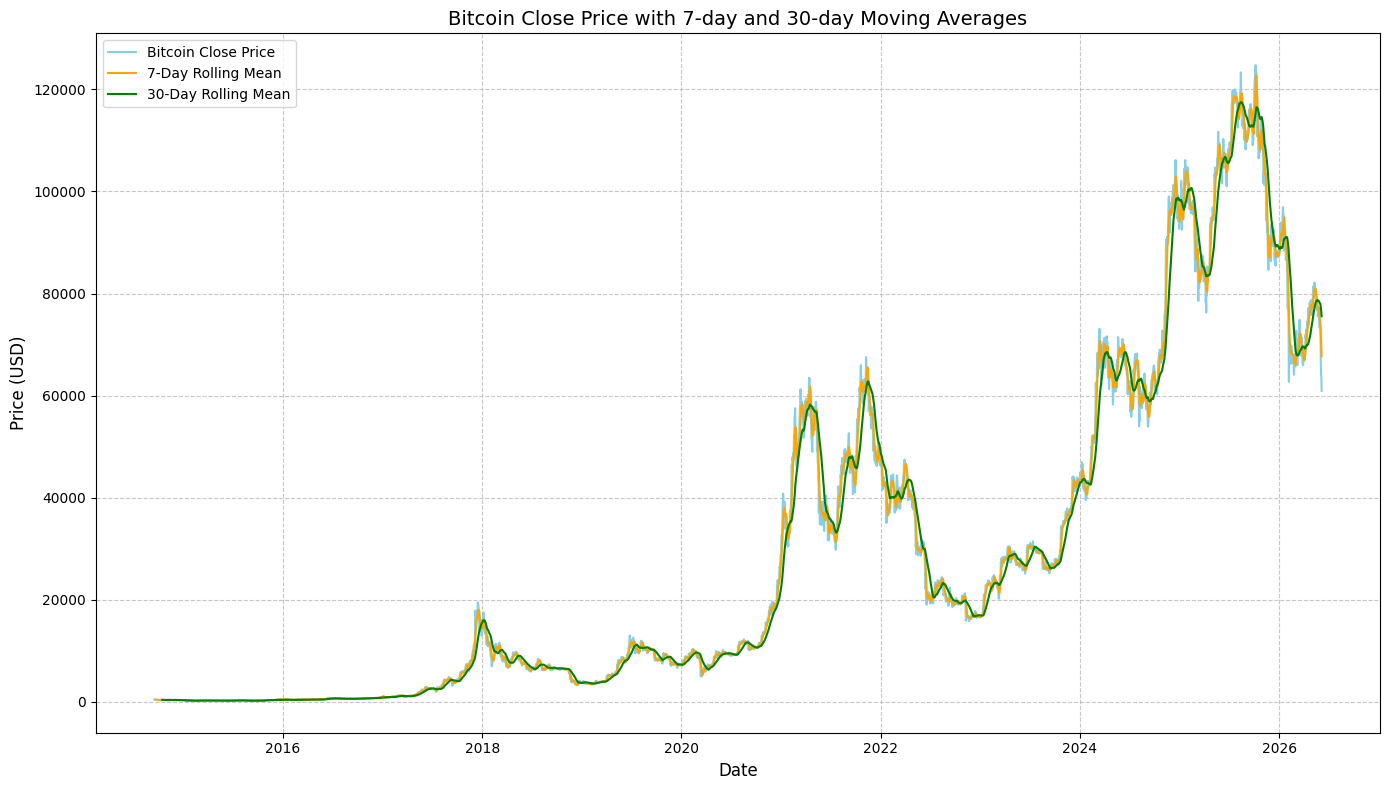

In [20]:
plt.figure(figsize=(14, 8))
plt.plot(bitcoin_drop.index, bitcoin_drop['Close'], label='Bitcoin Close Price', color='skyblue')
plt.plot(bitcoin_drop.index, bitcoin_drop['7DR'], label='7-Day Rolling Mean', color='orange')
plt.plot(bitcoin_drop.index, bitcoin_drop['30DR'], label='30-Day Rolling Mean', color='green')

plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.title('Bitcoin Close Price with 7-day and 30-day Moving Averages', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

 Top 10 most volatile days

In [21]:
bitcoin_drop.sort_values(by = 'Rolling 30-day Daily Return', ascending=True).head(10)

,Open,High,Low,Close,Volume,year,month,day,daily return,Daily Range,Log Return,Rolling 30-day Daily Return,7DR,30DR
Date,,,,,,,,,,,,,,
2016-10-09,619.171997,619.197998,616.606995,616.752014,39243400,2016,10,9,-0.000039,2.591003,-0.003813,0.000071,614.407131,608.858366
2016-10-10,616.822021,621.317993,616.197021,618.994019,67481104,2016,10,10,0.000035,5.120972,0.003629,0.000071,615.387277,608.707867
2016-10-08,617.341003,619.848999,617.341003,619.107971,42345900,2016,10,8,0.000029,2.507996,0.003215,0.000071,613.569990,609.062000
2016-04-18,427.610992,429.273987,427.085999,428.591003,55670900,2016,4,18,0.000023,2.187988,0.002785,0.000071,427.068717,421.280733
2016-04-17,430.635986,431.371002,426.079010,427.398987,52125900,2016,4,17,-0.000075,5.291992,-0.007397,0.000071,426.196145,420.675833
2016-04-19,428.703003,436.019989,428.104004,435.509003,52810500,2016,4,19,0.000159,7.915985,0.016012,0.000075,428.542860,422.005866
2016-04-20,435.324005,443.053986,434.406006,441.389008,72890096,2016,4,20,0.000139,8.647980,0.013411,0.000079,431.065002,422.941933
2016-10-06,612.469971,613.818970,611.468994,613.020996,56812100,2016,10,6,0.000009,2.349976,0.000832,0.000079,611.782706,609.216368
2016-10-07,612.607971,617.911987,611.820984,617.120972,64071400,2016,10,7,0.000074,6.091003,0.006666,0.000079,612.837847,609.302266


Correlation between volume and price change

In [22]:
bitcoin_drop.Volume.corr(bitcoin_drop['Open']-bitcoin_drop['Close'])

np.float64(0.027347971345487894)

Average volume by year

In [23]:
avg_volume =(bitcoin_drop.groupby(bitcoin_drop.index.year)['Volume'].mean())
avg_volume

,Volume
Date,
2014,2.383690e+07
2015,3.390557e+07
2016,8.592451e+07
2017,2.382867e+09
2018,6.063552e+09
2019,1.673049e+10
2020,3.302327e+10
2021,4.715574e+10
2022,3.001327e+10


Ploting volume as a bar chart under the price line chart

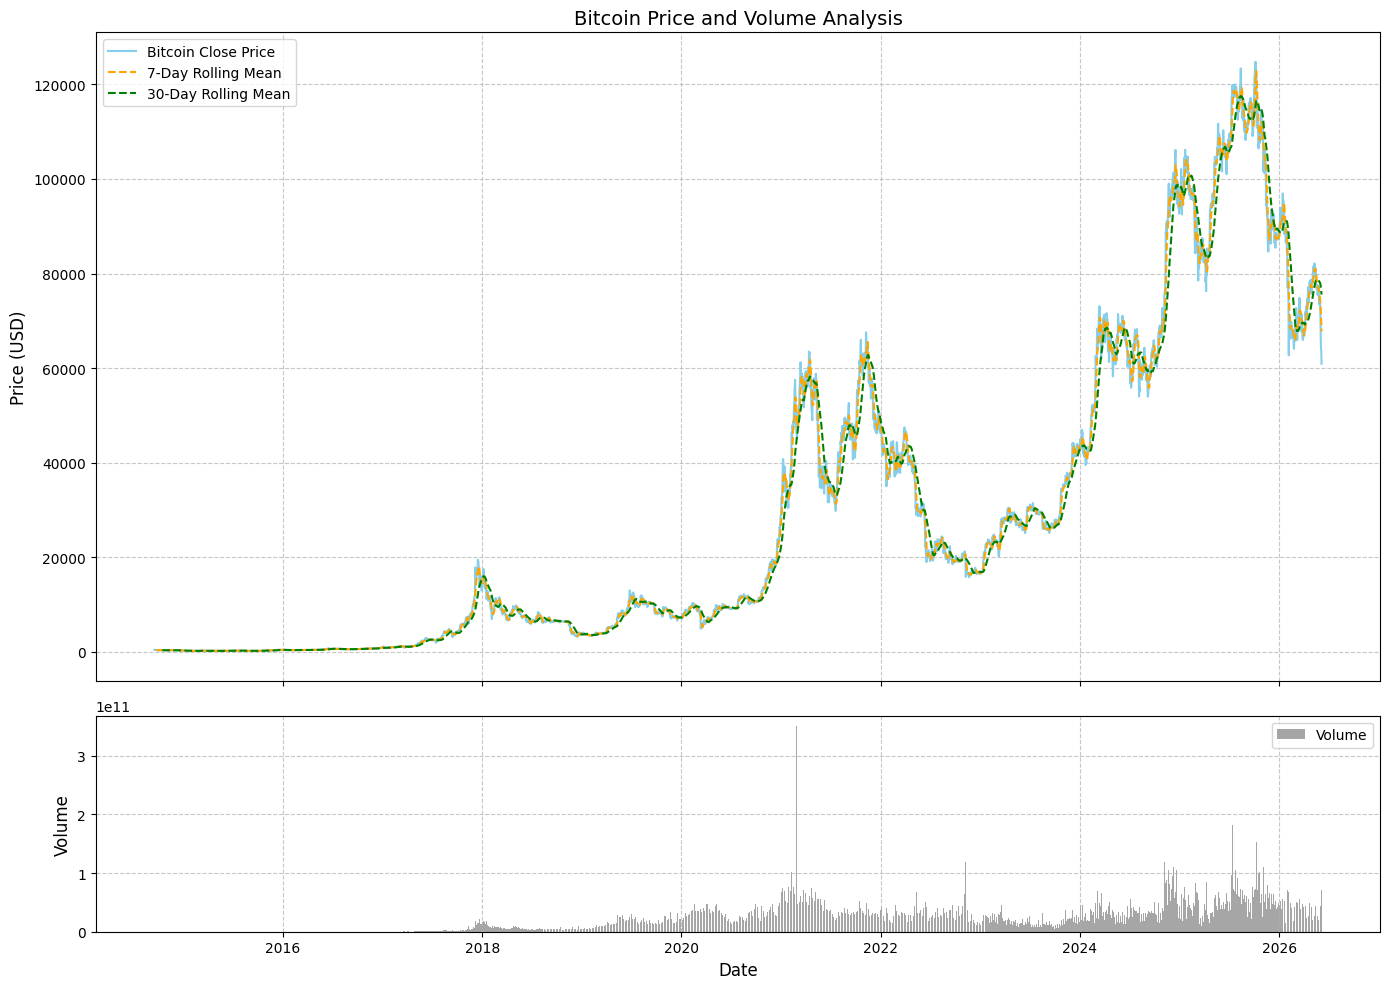

In [24]:
# Create a figure and a set of subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Plotting Price on the first subplot (ax1)
ax1.plot(bitcoin_drop.index, bitcoin_drop['Close'], label='Bitcoin Close Price', color='skyblue')
ax1.plot(bitcoin_drop.index, bitcoin_drop['7DR'], label='7-Day Rolling Mean', color='orange', linestyle='--')
ax1.plot(bitcoin_drop.index, bitcoin_drop['30DR'], label='30-Day Rolling Mean', color='green', linestyle='--')
ax1.set_ylabel('Price (USD)', fontsize=12)
ax1.set_title('Bitcoin Price and Volume Analysis', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# Plotting Volume on the second subplot (ax2)
ax2.bar(bitcoin_drop.index, bitcoin_drop['Volume'], label='Volume', color='grey', alpha=0.7)
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Volume', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()

In [25]:
Best_days = bitcoin_drop['daily return'].idxmax()
Best_days

Timestamp('2017-12-07 00:00:00')

In [26]:
Worse_days = bitcoin_drop['daily return'].idxmin()
Worse_days

Timestamp('2020-03-12 00:00:00')

In [27]:
Best_year = bitcoin_drop.groupby(bitcoin_drop.index.year)['daily return'].idxmax()
Best_year

,daily return
Date,
2014,2014-11-12
2015,2015-01-15
2016,2016-05-28
2017,2017-12-07
2018,2018-04-12
2019,2019-04-02
2020,2020-03-19
2021,2021-02-08
2022,2022-02-28


In [28]:
worse_year = bitcoin_drop.groupby(bitcoin_drop.index.year)['daily return'].idxmin()
worse_year

,daily return
Date,
2014,2014-10-04
2015,2015-01-14
2016,2016-01-15
2017,2017-09-14
2018,2018-01-16
2019,2019-06-27
2020,2020-03-12
2021,2021-05-19
2022,2022-06-13


In [29]:
start_price = bitcoin_drop.Close.iloc[0]
start_date =bitcoin_drop.index[0]
print(f'\nstarting pprice on {start_date.date()}: ${start_price:,.1f}\n')

for multiples in [10, 100, 200]:
  Target = start_price*multiples
  crossed = bitcoin_drop[bitcoin_drop.Close>=Target]
  if not crossed.empty:
    reached =crossed.index[0]
    days = (reached-start_date).days
    years =days/365.25 #considering the leap year
    print(f' {multiples:>3}x → Target ${Target:>10,.0f} '
          f'reached on {reached.date()}'
          f'({days:,} days/ {years:.1f}years)')
  else:
    print(f'{multiples:>3}x → Target ${Target:>10,.0f} not yet reachead in dataset')




starting pprice on 2014-09-17: $457.3

  10x → Target $     4,573 reached on 2017-08-29(1,077 days/ 2.9years)
 100x → Target $    45,733 reached on 2021-02-08(2,336 days/ 6.4years)
 200x → Target $    91,467 reached on 2024-11-19(3,716 days/ 10.2years)


In [30]:
rolling_max = bitcoin_drop['Close'].cummax()
drawdown    = (bitcoin_drop['Close'] - rolling_max) / rolling_max * 100

print("\nTop 5 Deepest Crash Points:")
for date, val in drawdown.nsmallest(5).items():
    peak   = rolling_max.loc[date]
    trough = bitcoin_drop.loc[date, 'Close']
    print(f"  {date.date()}  →  {val:.1f}%  "
          f"(peak ${peak:>10,.0f}  →  trough ${trough:>10,.0f})")

max_dd_date = drawdown.idxmin()
print(f"\n  Maximum Drawdown Ever : {drawdown.min():.1f}%  on {max_dd_date.date()}")


Top 5 Deepest Crash Points:
  2018-12-15  →  -83.4%  (peak $    19,497  →  trough $     3,237)
  2018-12-14  →  -83.4%  (peak $    19,497  →  trough $     3,242)
  2018-12-16  →  -83.3%  (peak $    19,497  →  trough $     3,253)
  2018-12-13  →  -83.0%  (peak $    19,497  →  trough $     3,314)
  2019-02-07  →  -82.6%  (peak $    19,497  →  trough $     3,399)

  Maximum Drawdown Ever : -83.4%  on 2018-12-15


In [31]:
total_days    = len(bitcoin_drop)
positive_days = (bitcoin_drop['daily return'] > 0).sum()
negative_days = (bitcoin_drop['daily return'] < 0).sum()
overall_ret   = (bitcoin_drop['Close'].iloc[-1] - bitcoin_drop['Close'].iloc[0]) / bitcoin_drop['Close'].iloc[0] * 100
ann_vol       = bitcoin_drop['Log Return'].std() * np.sqrt(365) * 100

In [32]:
vol_corr = bitcoin_drop['Volume'].corr(bitcoin_drop['Open'] - bitcoin_drop['Close'])

print(f"""
  Period              : {bitcoin_drop.index[0].date()} → {bitcoin_drop.index[-1].date()}
  Total trading days  : {total_days:,}

  Starting price      : ${bitcoin_drop['Close'].iloc[0]:>12,.2f}
  Latest price        : ${bitcoin_drop['Close'].iloc[-1]:>12,.2f}
  All-time high       : ${bitcoin_drop['High'].max():>12,.2f}  on {bitcoin_drop['High'].idxmax().date()}
  All-time low        : ${bitcoin_drop['Low'].min():>12,.2f}  on {bitcoin_drop['Low'].idxmin().date()}

  Total return        : +{overall_ret:,.0f}%
  Annualised vol      : {ann_vol:.1f}%

  Green days          : {positive_days:,}  ({positive_days/total_days*100:.1f}%)
  Red days            : {negative_days:,}  ({negative_days/total_days*100:.1f}%)

  Vol ↔ Price move corr : {vol_corr:.4f}  (near zero = volume doesn't predict direction)
""")


  Period              : 2014-09-17 → 2026-06-05
  Total trading days  : 4,280

  Starting price      : $      457.33
  Latest price        : $   60,922.67
  All-time high       : $  126,198.07  on 2025-10-06
  All-time low        : $      171.51  on 2015-01-14

  Total return        : +13,221%
  Annualised vol      : 67.1%

  Green days          : 2,243  (52.4%)
  Red days            : 2,037  (47.6%)

  Vol ↔ Price move corr : 0.0273  (near zero = volume doesn't predict direction)

